# Работа по теме "Методы классификации"

## Описание

Работа предполагает самостоятельное исследование данных и построение классификационных моделей.

Основная задача работы - научиться работать с методами классификации, настраивать и отбирать лучшие модели.

Предлагается два набора данных. Первый предлагается для отработки изученных моделей, метрик и методов работы с данными. Второй набор предлагается для возможности отработки методов работы с текстовыми данными.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- рассмотрено не менее трех различных методов классификации;
- создаваемые модели натроены для получения наилучших результатов;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы;
- верно использованы различные подходы к обработке текста.

В результате необходимо получить наилучшую модель классификации для числовых данных, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс выбора и настройки моделей. Для текстовых данных необходимо получить результат, показав процесс обработки текста.

@MSorokin

**Задача:** по астрофизическим параметрам звезды предсказать её эволюционную фазу:
- **Phase 1** — RGB (Red Giant Branch): звезда сжигает водород в оболочке вокруг гелиевого ядра
- **Phase 2** — RC (Red Clump): звезда сжигает гелий в ядре

## Импорт библиотек

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

## Вспомогательная функция для метрик

Удобно один раз написать функцию, которая выводит и отчёт по метрикам, и матрицу ошибок в виде тепловой карты.

In [90]:
def metrics(y_true, y_pred, title='Матрица ошибок'):
    print(classification_report(y_true, y_pred, target_names=['Phase 1 (RGB)', 'Phase 2 (RC)']))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Pred: 1', 'Pred: 2'],
                yticklabels=['Actual: 1', 'Actual: 2'])
    plt.title(title)
    plt.xlabel('Предсказание')
    plt.ylabel('Факт')
    plt.show()

## 1. Загрузка и исследование данных

In [91]:
df = pd.read_csv('Data_classified_phase.csv')
df.head()

,Kpmag,numax,e_numax,Delnu,e_Delnu,A,e_A,Width,e_Width,Teff,...,e_NoCorR,RGBcorM,e_RGBcorM,RGBcorR,e_RGBcorR,ClcorM,e_ClcorM,ClcorR,e_ClcorR,Phase
0,9.20,29.99,0.60,3.399,0.011,104.9,4.6,12.3,1.5,4751,...,0.41,1.55,0.13,13.26,0.39,1.72,0.14,13.97,0.41,1
1,13.23,29.48,0.48,3.962,0.116,149.7,8.3,12.0,3.9,5188,...,0.68,1.04,0.15,10.74,0.70,1.00,0.14,10.52,0.68,2
2,12.58,41.39,0.54,4.311,0.013,86.1,4.6,15.3,1.6,4728,...,0.26,1.54,0.09,11.29,0.24,1.72,0.10,11.92,0.26,1
3,12.14,41.17,0.90,4.414,0.061,63.8,2.9,24.8,2.7,5072,...,0.48,1.67,0.17,11.55,0.48,1.75,0.18,11.83,0.49,2
4,11.74,36.91,0.71,3.991,0.064,116.1,9.6,14.0,2.4,4718,...,0.53,1.50,0.16,11.80,0.50,1.67,0.17,12.43,0.53,2


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15388 entries, 0 to 15387
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Kpmag      15388 non-null  float64
 1   numax      15388 non-null  float64
 2   e_numax    15388 non-null  float64
 3   Delnu      15388 non-null  float64
 4   e_Delnu    15388 non-null  float64
 5   A          15388 non-null  object 
 6   e_A        15388 non-null  object 
 7   Width      15388 non-null  object 
 8   e_Width    15388 non-null  object 
 9   Teff       15388 non-null  int64  
 10  e_Teff     15388 non-null  int64  
 11  log(g)     15388 non-null  float64
 12  e_log(g)   15388 non-null  float64
 13  [Fe/H]     15388 non-null  float64
 14  e_[Fe/H]   15388 non-null  float64
 15  NoCorM     15388 non-null  float64
 16  e_NoCorM   15388 non-null  float64
 17  NoCorR     15388 non-null  float64
 18  e_NoCorR   15388 non-null  float64
 19  RGBcorM    15388 non-null  float64
 20  e_RGBc

Некоторые столбцы (`A`, `e_A`, `Width`, `e_Width`) определились как `object` вместо числового типа.
Преобразуем всё к числовому типу.

In [93]:
df = df.apply(pd.to_numeric, errors='coerce') # errors='coerce' чтобы функция с ошибкой не падала
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15388 entries, 0 to 15387
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Kpmag      15388 non-null  float64
 1   numax      15388 non-null  float64
 2   e_numax    15388 non-null  float64
 3   Delnu      15388 non-null  float64
 4   e_Delnu    15388 non-null  float64
 5   A          14851 non-null  float64
 6   e_A        14851 non-null  float64
 7   Width      14851 non-null  float64
 8   e_Width    14851 non-null  float64
 9   Teff       15388 non-null  int64  
 10  e_Teff     15388 non-null  int64  
 11  log(g)     15388 non-null  float64
 12  e_log(g)   15388 non-null  float64
 13  [Fe/H]     15388 non-null  float64
 14  e_[Fe/H]   15388 non-null  float64
 15  NoCorM     15388 non-null  float64
 16  e_NoCorM   15388 non-null  float64
 17  NoCorR     15388 non-null  float64
 18  e_NoCorR   15388 non-null  float64
 19  RGBcorM    15388 non-null  float64
 20  e_RGBc

In [94]:
df.describe()

,Kpmag,numax,e_numax,Delnu,e_Delnu,A,e_A,Width,e_Width,Teff,...,e_NoCorR,RGBcorM,e_RGBcorM,RGBcorR,e_RGBcorR,ClcorM,e_ClcorM,ClcorR,e_ClcorR,Phase
count,15388.000000,15388.000000,15388.000000,15388.00000,15388.000000,14851.000000,14851.000000,14851.000000,14851.000000,15388.00000,...,15388.000000,15388.000000,15388.000000,15388.000000,15388.00000,15388.000000,15388.000000,15388.000000,15388.000000,15388.000000
mean,12.632402,64.673195,0.903276,6.16765,0.047327,95.059174,5.328045,20.241620,2.009454,4903.08994,...,0.407304,1.344886,0.126670,9.720831,0.39403,1.422839,0.134646,10.024309,0.409406,1.500585
std,1.211778,50.958690,0.891080,3.56072,0.069763,51.897428,5.110774,11.734342,2.181685,212.91843,...,0.452677,0.409900,0.106109,3.053634,0.42836,0.417293,0.114116,3.216817,0.453516,0.500016
min,6.240000,3.970000,0.040000,0.74700,0.008000,10.700000,0.700000,1.800000,0.200000,3225.00000,...,0.060000,0.340000,0.030000,3.240000,0.06000,0.430000,0.040000,3.470000,0.060000,1.000000
25%,11.900000,31.680000,0.560000,3.97675,0.017000,59.900000,2.800000,13.000000,1.100000,4769.00000,...,0.180000,1.100000,0.080000,7.880000,0.17000,1.170000,0.090000,8.160000,0.180000,1.000000
50%,12.850000,42.260000,0.720000,4.54050,0.028000,90.800000,4.400000,15.600000,1.400000,4907.00000,...,0.310000,1.270000,0.100000,10.220000,0.30000,1.350000,0.110000,10.520000,0.310000,2.000000
75%,13.510000,79.522500,1.000000,7.27000,0.050000,120.900000,6.000000,23.700000,2.000000,5047.00000,...,0.460000,1.480000,0.130000,11.160000,0.45000,1.580000,0.140000,11.450000,0.460000,2.000000
max,16.850000,273.160000,70.270000,19.29400,1.338000,745.200000,82.800000,101.200000,46.900000,6356.00000,...,9.800000,5.150000,2.800000,48.610000,9.00000,5.240000,2.950000,51.190000,9.800000,2.000000


### Распределение целевого признака

Сразу смотрим на баланс классов — это определяет, нужны ли специальные техники работы с дисбалансом.

In [95]:
df['Phase'].value_counts()

Phase
2    7703
1    7685
Name: count, dtype: int64

Классы практически идеально сбалансирован, это хорошо.

## 2. Предобработка

### Пропущенные значения

In [96]:
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0])
print(f'\nВсего строк: {len(df)}')
print(f'Строк с пропусками: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).mean():.1%})')

A          537
e_A        537
Width      537
e_Width    537
dtype: int64

Всего строк: 15388
Строк с пропусками: 537 (3.5%)


Пропуски присутствуют только в четырёх столбцах и составляют менее 4% от данных.
Удалим эти строки, вполне можем позволить себе это.

In [97]:
df = df.dropna()
df.shape

(14851, 28)

### Выбросы

Посмотрим на распределение значений через боксплоты. Строим только для физических признаков (без столбцов с погрешностями), чтобы не перегружать график.

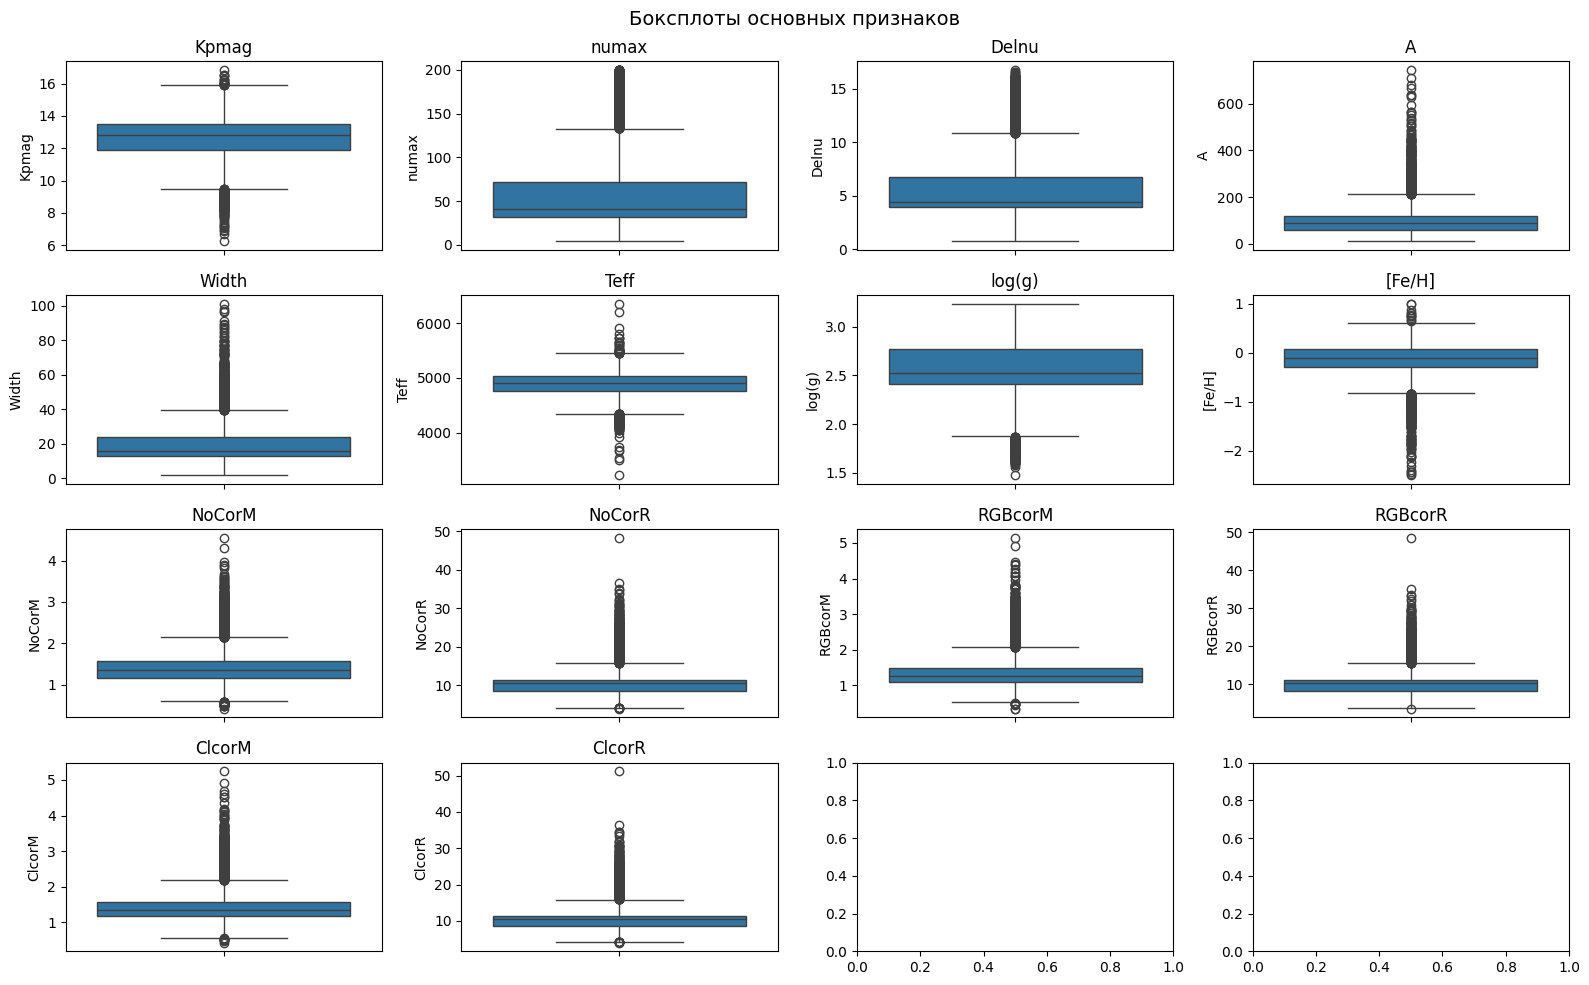

In [98]:
main_cols = [c for c in df.columns if not c.startswith('e_') and c != 'Phase']

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(main_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Боксплоты основных признаков', fontsize=14)
plt.tight_layout()
plt.show()

Выбросы присутствуют, но в контексте астрофизических данных — это, возможно, реальные объекты с экстремальными параметрами, а не ошибки измерений.
Удалять их не будем, чтобы не потерять информацию о разнообразии звёзд.

## 3. Корреляционный анализ и отбор признаков

### Корреляция с целевым признаком

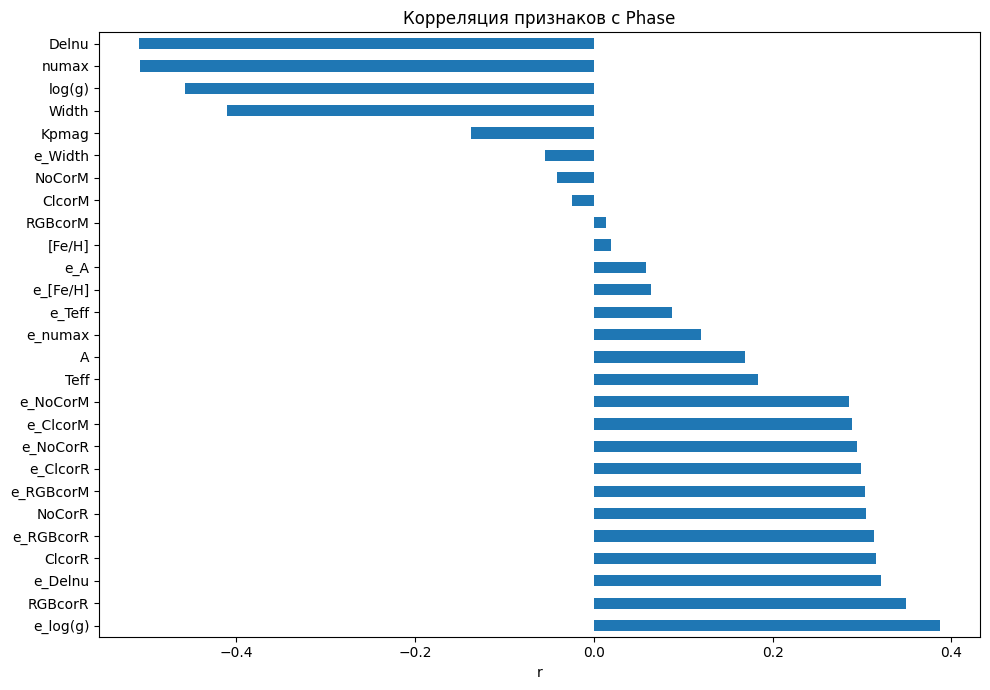

e_log(g)     0.387203
RGBcorR      0.348708
e_Delnu      0.320702
ClcorR       0.315257
e_RGBcorR    0.312857
NoCorR       0.304154
e_RGBcorM    0.303631
e_ClcorR     0.299135
e_NoCorR     0.294627
e_ClcorM     0.288437
e_NoCorM     0.285395
Teff         0.183703
A            0.169503
e_numax      0.119573
e_Teff       0.087725
e_[Fe/H]     0.064270
e_A          0.058018
[Fe/H]       0.019410
RGBcorM      0.013977
ClcorM      -0.024521
NoCorM      -0.041142
e_Width     -0.054424
Kpmag       -0.137581
Width       -0.410452
log(g)      -0.457123
numax       -0.507836
Delnu       -0.508677
Name: Phase, dtype: float64

In [99]:
corr_target = df.corr()['Phase'].drop('Phase').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr_target.plot(kind='barh')
plt.title('Корреляция признаков с Phase')
plt.xlabel('r')
plt.tight_layout()
plt.show()

corr_target

Сильнее всего с фазой коррелируют: `Delnu` (большое частотное расстояние), `numax` (частота максимума мощности), `log(g)` (поверхностная гравитация).

### Взаимная корреляция признаков

Сильно коррелированные между собой признаки несут одинаковую информацию — лишние можно убрать.

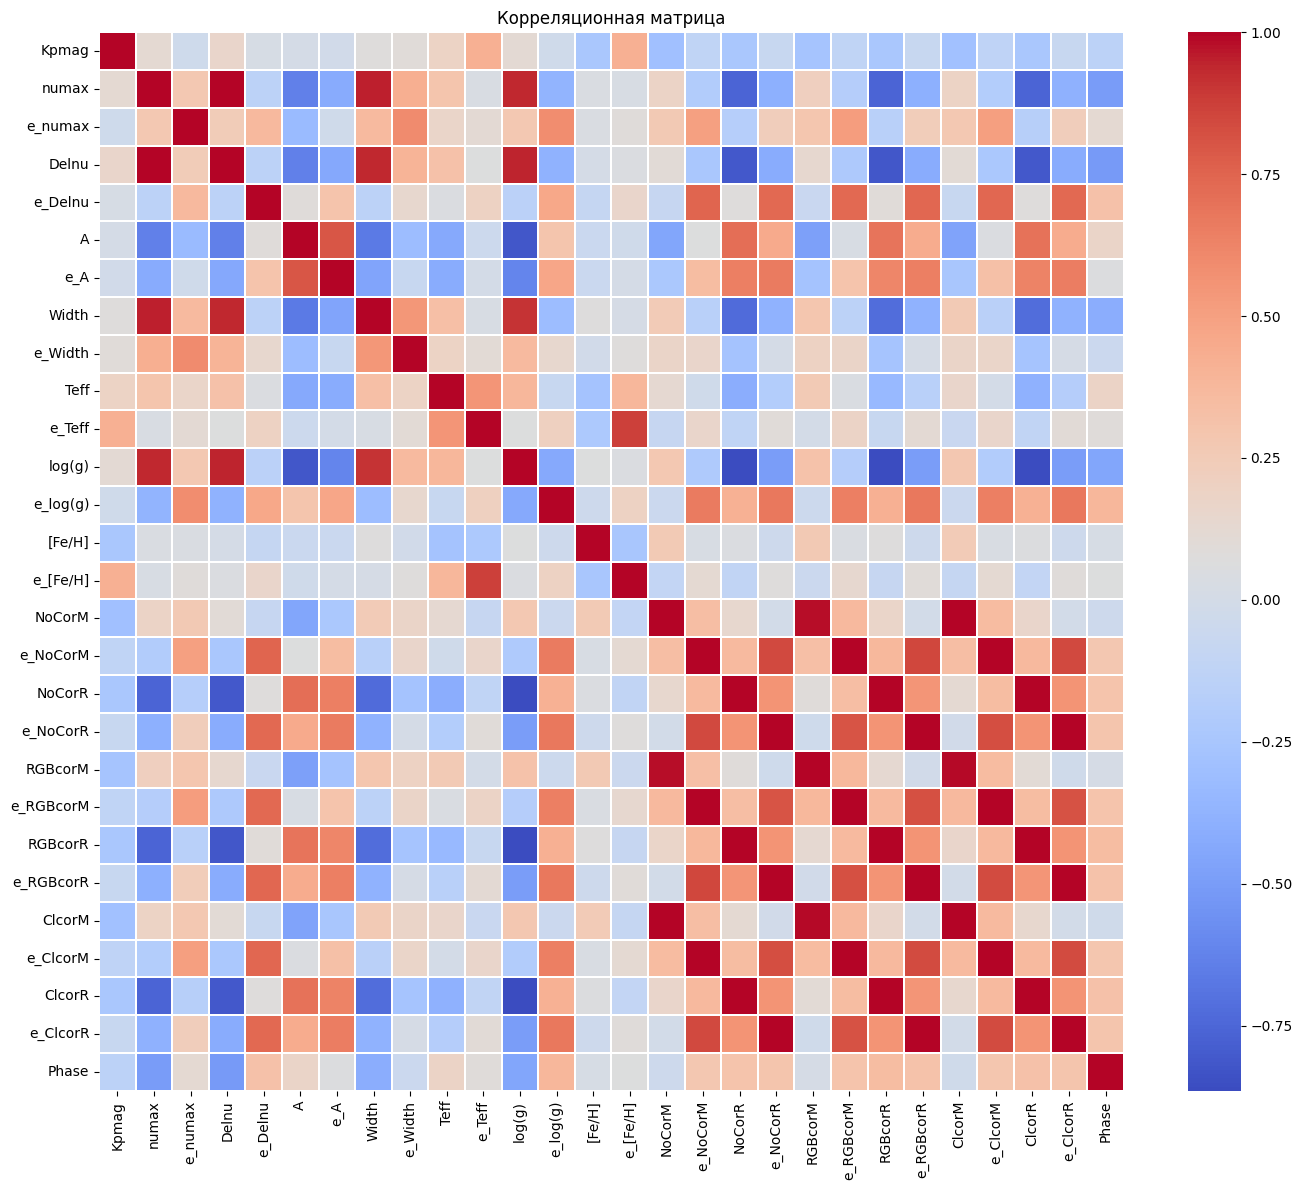

In [100]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.1)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Видны группы почти идеально коррелированных признаков — разные варианты коррекций для массы и радиуса (`NoCorM`, `RGBcorM`, `ClcorM` и их радиусные аналоги).
Оставим только одну версию из каждой группы. Аналогично, `numax` и `Delnu` коррелируют с r≈0.995, удалим один из них.

In [101]:
# Удаляем дублирующие признаки:
drop_cols = ['RGBcorM', 'ClcorM', 'e_RGBcorM', 'e_ClcorM',
             'RGBcorR', 'ClcorR', 'e_RGBcorR', 'e_ClcorR',
             'numax']

df_model = df.drop(columns=drop_cols)
display(f'Признаков до отбора: {df.shape[1] - 1}')
display(f'Признаков после отбора: {df_model.shape[1] - 1}')
display('Оставшиеся признаки:')
[c for c in df_model.columns if c != 'Phase']

'Признаков до отбора: 27'

'Признаков после отбора: 18'

'Оставшиеся признаки:'

['Kpmag',
 'e_numax',
 'Delnu',
 'e_Delnu',
 'A',
 'e_A',
 'Width',
 'e_Width',
 'Teff',
 'e_Teff',
 'log(g)',
 'e_log(g)',
 '[Fe/H]',
 'e_[Fe/H]',
 'NoCorM',
 'e_NoCorM',
 'NoCorR',
 'e_NoCorR']

## 4. Разделение на обучающую и тестовую выборки

In [102]:
X = df_model.drop('Phase', axis=1)
y = df_model['Phase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

display(f'Обучающая выборка: {X_train.shape}')
display(f'Тестовая выборка:  {X_test.shape}')
display(f'Распределение классов в train:') 
display(y_train.value_counts())
display(f'Распределение классов в test:')
display(y_test.value_counts())

'Обучающая выборка: (11880, 18)'

'Тестовая выборка:  (2971, 18)'

'Распределение классов в train:'

Phase
2    6162
1    5718
Name: count, dtype: int64

'Распределение классов в test:'

Phase
2    1541
1    1430
Name: count, dtype: int64

Параметр `stratify=y` гарантирует, что соотношение классов в обеих выборках сохранится.

### Нормализация

kNN и логистическая регрессия чувствительны к масштабу признаков, поэтому создадим нормализованные версии выборок.
`fit_transform` применяется только к обучающей выборке, `transform` — к тестовой, чтобы не допустить утечки данных.

In [103]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 5. Модели классификации

### Модель 1: k ближайших соседей

Выберем k=15 для начала.

               precision    recall  f1-score   support

Phase 1 (RGB)       0.95      0.93      0.94      1430
 Phase 2 (RC)       0.94      0.96      0.95      1541

     accuracy                           0.95      2971
    macro avg       0.95      0.94      0.95      2971
 weighted avg       0.95      0.95      0.95      2971



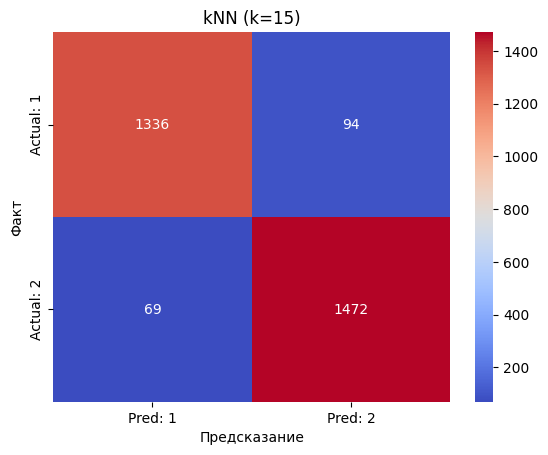

In [104]:
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_sc, y_train)

knn_pred = knn.predict(X_test_sc)
metrics(y_test, knn_pred, 'kNN (k=15)')

Подберём оптимальное `k`, перебрав несколько значений.

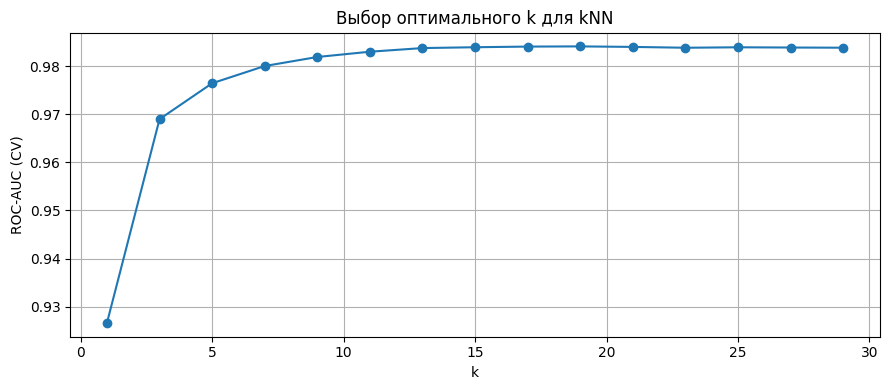

Лучшее k = 19, ROC-AUC = 0.9841


In [105]:
k_values = range(1, 31, 2)
scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                          X_train_sc, y_train, cv=5, scoring='roc_auc').mean()
          for k in k_values]

plt.figure(figsize=(9, 4))
plt.plot(k_values, scores, marker='o')
plt.xlabel('k')
plt.ylabel('ROC-AUC (CV)')
plt.title('Выбор оптимального k для kNN')
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(scores)]
print(f'Лучшее k = {best_k}, ROC-AUC = {max(scores):.4f}')

In [106]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
knn_pred = knn_best.predict(X_test_sc)
knn_auc = roc_auc_score(y_test, knn_best.predict_proba(X_test_sc)[:, 1])
print(f'kNN (k={best_k}) — ROC-AUC на тесте: {knn_auc:.4f}')

kNN (k=19) — ROC-AUC на тесте: 0.9840


### Модель 2: Логистическая регрессия

Линейная модель — хороший ориентир.

               precision    recall  f1-score   support

Phase 1 (RGB)       0.95      0.93      0.94      1430
 Phase 2 (RC)       0.93      0.95      0.94      1541

     accuracy                           0.94      2971
    macro avg       0.94      0.94      0.94      2971
 weighted avg       0.94      0.94      0.94      2971



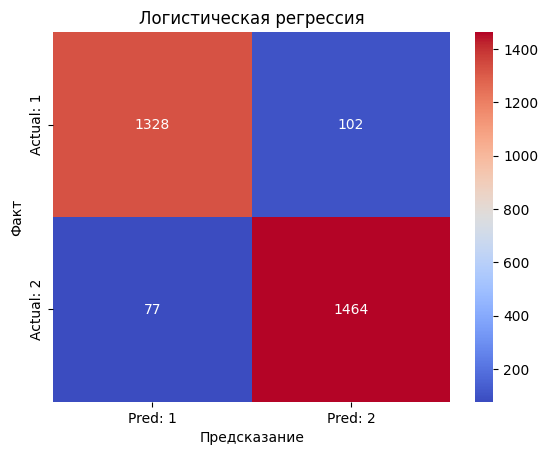

In [107]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
metrics(y_test, lr_pred, 'Логистическая регрессия')

In [108]:
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1])
print(f'Логистическая регрессия — ROC-AUC на тесте: {lr_auc:.4f}')

Логистическая регрессия — ROC-AUC на тесте: 0.9816


### Модель 3: Случайный лес

Ансамблевый метод, не требующий нормализации.

               precision    recall  f1-score   support

Phase 1 (RGB)       0.96      0.96      0.96      1430
 Phase 2 (RC)       0.96      0.96      0.96      1541

     accuracy                           0.96      2971
    macro avg       0.96      0.96      0.96      2971
 weighted avg       0.96      0.96      0.96      2971



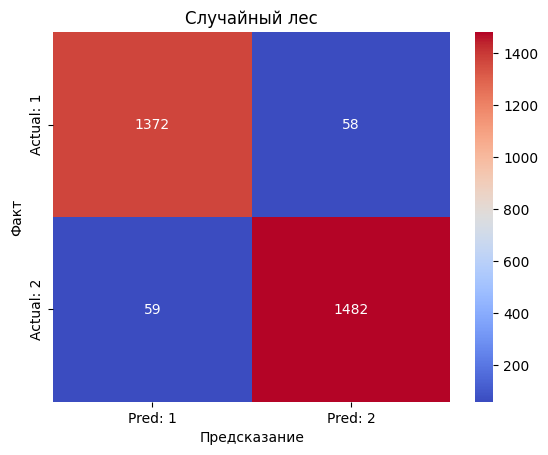

In [109]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
metrics(y_test, rf_pred, 'Случайный лес')

In [110]:
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f'Случайный лес — ROC-AUC на тесте: {rf_auc:.4f}')

Случайный лес — ROC-AUC на тесте: 0.9917


### Важность признаков

Случайный лес позволяет оценить, какие признаки он считает наиболее значимыми.

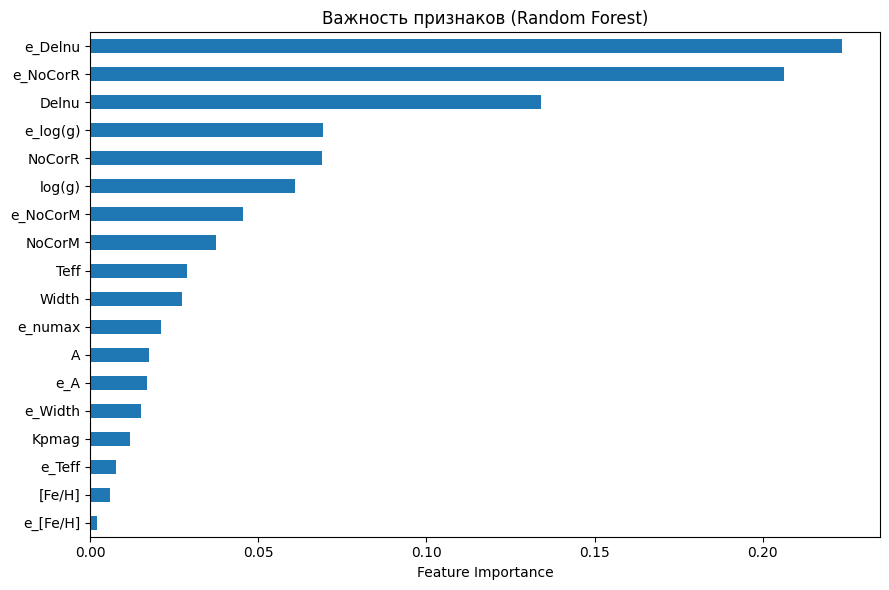

In [111]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh')
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## 6. Подбор гиперпараметров: GridSearchCV

Случайный лес показал лучший результат. Настроим его с помощью `GridSearchCV`.
Метрика — **ROC-AUC**: она измеряет способность модели разделять классы и не зависит от порога классификации.

In [112]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Лучший ROC-AUC (CV): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры: {'max_depth': 16, 'min_samples_split': 5, 'n_estimators': 200}
Лучший ROC-AUC (CV): 0.9909


## 7. Итоговая модель

Обучаем финальную модель с оптимальными гиперпараметрами.

               precision    recall  f1-score   support

Phase 1 (RGB)       0.96      0.96      0.96      1430
 Phase 2 (RC)       0.97      0.96      0.96      1541

     accuracy                           0.96      2971
    macro avg       0.96      0.96      0.96      2971
 weighted avg       0.96      0.96      0.96      2971



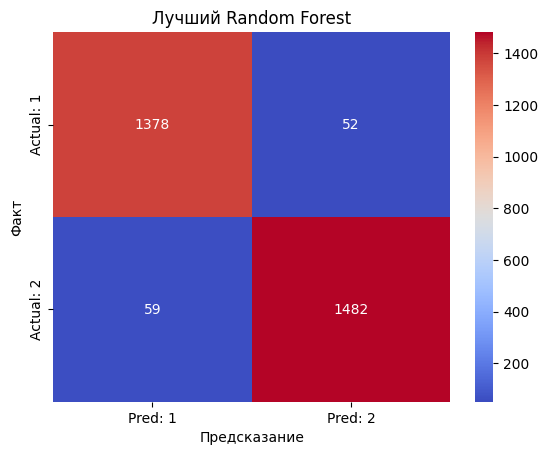

In [113]:
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)[:, 1]

metrics(y_test, best_pred, 'Лучший Random Forest')

In [114]:
best_auc = roc_auc_score(y_test, best_proba)
best_auc

0.9919228727145665

## Выводы

**Лучшая модель** — Случайный лес (Random Forest), настроенный через GridSearchCV.

**Ключевые наблюдения:**
- Задача решается с высокой точностью: Random Forest достигает ROC-AUC > 0.97
- Наиболее важные признаки — `Delnu`, `log(g)`, `numax`: это астрофизически обоснованные разделители эволюционных фаз
- Логистическая регрессия также даёт хороший результат, что говорит о том, что между классами есть хорошее линейное разделение
- kNN уступает ансамблевым и линейным методам в данной задаче